In [1]:
infopath = "BACZUB/BACZUB.info"

In [2]:
from cell2mol.read_write import readinfo
from cell2mol.classes import cell
from cell2mol.cell_reconstruction import classify_fragments, fragments_reconstruct
from cell2mol.charge_assignment import *

In [3]:
name = "BACZUB"

In [4]:
debug=2

In [5]:
print(f"INITIATING cell object from input") 

# Reads reference molecules from info file, as well as labels and coordinates
labels, pos, ref_labels, ref_fracs, cellvec, cellparam = readinfo(infopath)
# Initiates cell
newcell = cell(name, labels, pos, cellvec, cellparam)

# Loads the reference molecules and checks_missing_H
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=debug) 
newcell.assess_errors()

INITIATING cell object from input
MOLECULE.SPLIT COMPLEX: labels=['Hg', 'Fe', 'Cl', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H']
MOLECULE.SPLIT COMPLEX: metal_idx=[0, 1]
MOLECULE.SPLIT COMPLEX: rest_idx=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
SPLIT COMPLEX: rest labels: ['Cl', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H']
SPLIT COMPLEX: rest coord: [[-0.3928769966037601, 2.3016163714687834, 7.603055514033566], [1.088207063968434, 4.309352587547709, 1.5686258268701916], [0.7532516276954522, 5.168808941441503, 1.697896237810325], [1.0397715909633676, 3.638400052685908, 0.36499880736037693], [0.6781788850937274, 3.946031481417394, -0.4334360837404476], [1.6288999872619745, 2.4157695326489255, 0.5757421663720231], [1.7526494162892954, 1.7496592112398208, -0.06517835845721018], [2.047083955789577, 2.334447308344994, 1.9879399329449103], [2.465130185355504, 1.62

In [6]:
for mol in newcell.refmoleclist:
    if mol.iscomplex:
        print(mol.formula, mol.is_haptic, mol.haptic_type)

H9-C10-Cl-Fe-Hg True ['h5-Cp']
H9-C10-Cl-Fe-Hg True ['h5-Cp']
Cl6-Hg2 False []


In [7]:
for mol in newcell.refmoleclist:
    if mol.iscomplex:
        print(mol.formula, mol.is_haptic, mol.haptic_type)
        for lig in mol.ligands:
            print("|-", lig.formula)
            for group in lig.groups:
                print("|--", group.formula, group.is_haptic, group.haptic_type)
        for met in mol.metals:
            print("***")
            print(met.label, met.coord_nr, met.coord_geometry, met.geom_deviation)
            for group in met.groups:
                print("|-", group.formula, group.is_haptic, group.haptic_type)
                # print("|-", group.checked_coordination, group.denticity)
                print("|-", group.metals)
                # group.check_coordination(debug=debug)
            

H9-C10-Cl-Fe-Hg True ['h5-Cp']
|- H5-C5
|-- C5 True ['h5-Cp']
|- H4-C5
|-- C5 True ['h5-Cp']
|- Cl
|-- Cl False []
***
Hg 2 Linear 0.12
|- C False []
|- [------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Hg
 Atomic Number                = 80
 Index in Molecule            = 0
 Metal Adjacency (mconnec)    = 2
 Regular Adjacencies (connec) = 2
----------------------------------------------------
, ------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Number                = 26
 Index in Molecule            = 1
 Metal Adjacency (mconnec)    = 10
 Regular Adjacencies (connec) = 10
----------------------------------------------------
]
|- Cl False []
|- [------------- Cell2mol METAL Object -----------

In [8]:
group

------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Origin                       = split_ligand
 Number of Metals             = 2
---------------------------------------------------

In [14]:
from cell2mol.other import *
from cell2mol.coordination_sphere import get_thres_from_two_atoms


In [ ]:
def check_neighboring_atoms_mconnec (idx, group, metal, debug):
    
    atom = group.atoms[idx]
    neighbors = [ group.atoms[j] for j in atom.adjacency ]
    nb_dist_from_metal = [ get_dist(nb.coord, met.coord) for nb in neighbors]

    neighbors_mconnec =[]
    for nb, dist in zip(neighbors, nb_dist_from_metal) :
        thres = get_thres_from_two_atoms(metal.label, nb.label, debug=debug)
        if dist > thres :   pass
        else :              neighbors_mconnec.append(nb) 

    if debug >= 2 : 
        print(f"CHECK NEIGHBORS: {atom.label} connected to {[nb.label for nb in neighbors]}")
        print(f"CHECK NEIGHBORS: Among these neighbors, {[nb_m.label for nb_m in neighbors_mconnec]}") 

    if len(neighbors_mconnec) >= 2 :
        if debug >=1 : 
            print(f"CHECK NEIGHBORS:[Check] This coordinating atom {atom.label} connected to more than one coordinating atoms to the metal {metal.label}")
        if set([nb_m.label for nb_m in neighbors_mconnec]) == set(["H"]) :  
            isremoved = False
        else :  
            isremoved = True 
            if debug >=1 : print("CHECK NEIGHBORS: !!! Wrong metal-coordination assignment for Atom", idx, atom.label, get_dist(atom.coord, metal.coord), "due to neighboring atoms")
    
    elif len(neighbors_mconnec) == 1 :
        nb_m = neighbors_mconnec[0]
        if debug >=1 : print(f"CHECK NEIGHBORS: [Check] This coordinating atom {atom.label} connected to another coordinating atom {nb_m.label} to the metal {metal.label}")

        if (atom.label == "H" and nb_m.label in ["B", "O", "N", "C"]) :
            isremoved = True
            if debug >=1 : print("CHECK NEIGHBORS: !!! Wrong metal-coordination assignment for Atom", idx, atom.label, get_dist(atom.coord, metal.coord), "due to H")

        elif (atom.label in ["B", "O", "N", "C"] and nb_m.label == "H") :
            isremoved = False # H will be removed later
            if debug >=1 : print("CHECK NEIGHBORS: metal-coordination assignment for Atom", idx, atom.label, get_dist(atom.coord, metal.coord), "connected to H which will be removed later")

        else : # Check angle between metal-coordinating atoms               
            vector1 = np.subtract(np.array(atom.coord), np.array(nb_m.coord))
            vector2 = np.subtract(np.array(atom.coord), np.array(metal.coord))                        
            angle = np.degrees(get_angle(vector1, vector2))
            if angle < 55 :
                if debug >= 1 : print("CHECK NEIGHBORS: !!! Wrong metal-coordination assignment for Atom", idx, atom.label, get_dist(atom.coord, metal.coord), "due to the angle", round(angle,2))
                isremoved = True
            else :
                isremoved = False
    else :
        isremoved = False
        if debug >=1 : print(f"CHECK NEIGHBORS: There is no neighbor atom connected to the metal {metal.label}")
    
    return isremoved


In [ ]:
for idx, atom in enumerate(group.atoms):
    for met in group.metals:
        neighbors = [ group.atoms[j] for j in atom.adjacency ]
        nb_dist_from_metal = [ get_dist(nb.coord, met.coord) for nb in neighbors]
    
        neighbors_mconnec =[]
        for nb, dist in zip(neighbors, nb_dist_from_metal) :
            thres = get_thres_from_two_atoms(met.label, nb.label, debug=debug)
            if dist > thres :   pass
            else :              neighbors_mconnec.append(nb) 
            
        if debug >= 2 : 
            print(f"\t\t{atom.label} connected to {[nb.label for nb in neighbors]}")
            print(f"\t\tAmong these neighbors, {[nb_m.label for nb_m in neighbors_mconnec]}")



In [ ]:
## Second Correction
for idx, atom in enumerate(group.atoms):
    if debug >= 1 : print(f"\tSecond Correction with atom {idx}")
    metal = atom.get_closest_metal()
    dist = get_dist(atom.coord, metal.coord)
    thres = get_thres_from_two_atoms(metal.label, atom.label, debug=debug)
    if debug >= 1 : print(f"\tAtom {atom.label} connected to {metal.label} distance {get_dist(atom.coord, metal.coord)} with threshold {thres}")
    
    neighbors = [ group.atoms[j] for j in atom.adjacency ]
    nb_dist_from_metal = [ get_dist(nb.coord, metal.coord) for nb in neighbors]
    neighbors_mconnec =[]

    for nb, dist in zip(neighbors, nb_dist_from_metal) :
        thres = get_thres_from_two_atoms(metal.label, nb.label, debug=debug)
        if dist > thres :   pass
        else :              neighbors_mconnec.append(nb)   
    
    if debug >= 2 : 
        print(f"\t\t{atom.label} connected to {[nb.label for nb in neighbors]}")
        print(f"\t\tAmong these neighbors, {[nb_m.label for nb_m in neighbors_mconnec]}")                                                                               x                                                                  hnb_m in neighbors_mconnec]} are connected to the metal {metal.label}")

    if len(neighbors_mconnec) >= 2 :
        if debug >=1 : print(f"\t[Check] This coordinating atom {atom.label} connected to more than one coordinating atoms to the metal {metal.label}")
        if set([nb_m.label for nb_m in neighbors_mconnec]) == set(["H"]) :  pass  # TODO : Figure out why I put this condition
        else :  
            atom.reset_mconnec(metal, debug=debug)
            group.remove_atom(idx, debug=debug)
            isremoved = True 
            if debug >=1 : print("\t!!! Wrong metal-coordination assignment for Atom", idx, atom.label, get_dist(atom.coord, metal.coord), "due to neighboring atoms")

    elif len(neighbors_mconnec) == 1 :
        nb_m = neighbors_mconnec[0]
        if debug >=1 : print(f"\t[Check] This coordinating atom {atom.label} connected to another coordinating atom {nb_m.label} to the metal {metal.label}")

        if (atom.label == "H" and nb_m.label in ["B", "O", "N", "C"]) :
            atom.reset_mconnec(metal, debug=debug)
            group.remove_atom(idx, debug=debug)

            if debug >=1 : print("\t!!! Wrong metal-coordination assignment for Atom", idx, atom.label, get_dist(atom.coord, metal.coord), "due to H")
        elif (atom.label in ["B", "O", "N", "C"] and nb_m.label == "H") :
            if debug >=1 : print("\t!!! Wrong metal-coordination assignment for Atom", nb_m.label, get_dist(nb_m.coord, metal.coord), "due to H")
            nb_m.reset_mconnec() # put an index of nb_m in group
        else : # Check angle between metal-coordinating atoms               
            vector1 = np.subtract(np.array(atom.coord), np.array(nb_m.coord))
            vector2 = np.subtract(np.array(atom.coord), np.array(metal.coord))                        
            angle = np.degrees(get_angle(vector1, vector2))
            if angle < 55 :
                if debug >= 1 : print("\t!!! Wrong metal-coordination assignment for Atom", idx, atom.label, get_dist(atom.coord, metal.coord), "due to the angle", round(angle,2))
                atom.reset_mconnec(metal, debug=debug)
                group.remove_atom(idx, debug=debug)

    elif round(dist/thres, 3) > 0.95 :
        if debug >=1 : print("\t!!! Wrong metal-coordination assignment for Atom", idx, atom.label , get_dist(atom.coord, metal.coord), "due to the long distance")
        atom.reset_mconnec(metal, debug=debug)
        group.remove_atom(idx, debug=debug)
    else :
        if debug >=1 :print(f"\tThere is no neighbor atom connected to the metal {metal.label}")
        pass


In [9]:
newcell.check_missing_H(debug=debug)                                     


##################
Checking Missing H
##################
Not a Single Molecule has Missing H atoms (apparently)


False

In [10]:
for mol in newcell.refmoleclist:
    for met in mol.metals:
        print(met.label, met.coord_nr, met.coord_geometry, met.geom_deviation, met.rel_metal_radius)

Hg 2 Linear 0.12 0.981
Fe 2 Linear 0.007 0.729
Hg 2 Linear 0.12 0.981
Fe 2 Linear 0.007 0.729
Hg 4 Tetrahedral 1.839 1.14
Hg 4 Tetrahedral 1.839 1.14


In [11]:
newcell.reconstruct(debug=debug) 

CLASSIFY_FRAGMENTS. 12 Blocks sorted as (Molec, Frag, H): 0 8 4

##############################################
FRAG_RECONSTRUCT. 8 molecules submitted to SEQUENTIAL with Heavy
##############################################
goodlist=[]
avglist=[]
badlist=[------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = Heavy
 Number of Atoms              = 2
 Formula                      = Cl-Hg
 Has Adjacency Matrix         = YES
 Origin                       = cell.get_moleclist
 Number of Ligands            = 1
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = Heavy
 Number of Atoms              = 9
 Formula                      = H3-C5-Fe
 Has Adjacency Matrix         = YES
 Origin           

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Hg2
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 22
  Formula                      = H9-C10-Cl-Fe-Hg
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
  Number of Ligands            = 3
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version     

In [12]:
newcell.error_reconstruction

False

In [13]:
newcell.is_fragmented

False

In [14]:
newcell.refmoleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 22
  Formula                      = H9-C10-Cl-Fe-Hg
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 22
  Formula                      = H9-C10-Cl-Fe-Hg
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                  

In [15]:
newcell.moleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Hg2
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 22
  Formula                      = H9-C10-Cl-Fe-Hg
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
  Number of Ligands            = 3
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version     

In [16]:
newcell.get_unique_species(debug=debug)

Molecule 0 formula=Cl6-Hg2
New ligand found with: formula Cl added in position 0
COMPARE_SPECIES. Comparing:
------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
---------------------------------------------------

------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
---------------------------------------------------

['Cl']
['Cl']
mol1.adj_types=array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 

[------------- Cell2mol LIGAND Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 1
  Formula                      = Cl
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 0.1
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Hg
  Atomic Number                = 80
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 4
  Regular Adjacencies (connec) = 4
  Coordination Sphere Formula  = Cl4
 ----------------------------------------------------,
 ------------- Cell2mol LIGAND Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atom

In [17]:
selected_cs = []
for idx, spec in enumerate(newcell.unique_species):
#     print("doing", spec)
    if spec.subtype != "metal":
        spec.get_protonation_states()
        spec.get_possible_cs()
        print(spec.formula)
        selected_cs.append(list([cs.corr_total_charge for cs in spec.possible_cs]))
        print(f"{spec.protonation_states=}")
#         for prot in spec.protonation_states :
#              for sub_spec, sub_prot in zip(spec.coord, prot.coords):
#                 print(sub_spec, sub_prot, (sub_spec == sub_prot)) 
#         print("==========")     
#         for cs in spec.possible_cs :
#              for sub_spec, sub_cs_prot in zip(spec.coord, cs.protonation.coords):
#                 print(sub_spec, sub_cs_prot, (sub_spec == sub_cs_prot))     
                
#         print("==========")     
#         for prot, cs in  zip(spec.protonation_states, spec.possible_cs) :
#              for sub_prot, sub_cs_prot in zip(prot.coords, cs.protonation.coords):
#                 print(sub_prot, sub_cs_prot, (sub_prot == sub_cs_prot))   
    else :
        spec.get_possible_cs()
        selected_cs.append(spec.possible_cs)   
    print("")
print(selected_cs)

LIGAND.SPLIT_LIGAND: self.indices=[0]
LIGAND.SPLIT_LIGAND: conn_idx=[0]
LIGAND.SPLIT_LIGAND: conn_labels=['Cl']
LIGAND.SPLIT_LIGAND: conn_coord=[[3.4671199, 3.2061439, 5.7530764]]
LIGAND.SPLIT_LIGAND: conn_radii=[1.02]
blocklist=[[0]]
LIGAND.SPLIT_LIGAND: block=[0]
ADD_ATOM: Metalist length 1
ADD_ATOM: Ligand Atoms 1
ADD_ATOM: site= 0
ADD_ATOM: evaluating apos=array([3.4671199, 3.2061439, 5.7530764]) and tgt.coord=[2.8686395, 1.120505, 6.7807219]
ADD_ATOM: received tmpconnec[posadded]=1
ADD_ATOM: Chosen Metal index None. H is added at site 0
protonation_states=[------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['Cl']
 Type                            = Local
 Atoms added in positions        = [0]
 Atoms blocked (no atoms added)  = [1]
---------------------------------------------------
]
smiles='[Cl-]'
smiles='[Cl-]'
smiles='[Cl-]'
smiles='[Cl-]'
smiles='[Cl-]'
Cl
spec.protonation_states=[------------- Cell2mol

In [18]:
selected_cs

[[-1], [2], [-1], [-2], [2], [2, 3, 0]]

In [19]:
final_charge_distribution = balance_charge(newcell.unique_indices, newcell.unique_species, debug=debug)

BALANCE: iterlist [[-1], [2], [-1], [-2], [2], [2, 3, 0]]
BALANCE: unique_indices [0, 0, 0, 0, 0, 0, 1, 1, 2, 3, 0, 4, 5, 3, 2, 0, 4, 5]
BALANCE: tmpdistr [(-1, 2, -1, -2, 2, 2), (-1, 2, -1, -2, 2, 3), (-1, 2, -1, -2, 2, 0)]
BALANCE: alldistr added: [-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 2, -2, -1, -1, 2, 2]
d=[-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 2, -2, -1, -1, 2, 2]
BALANCE: alldistr added: [-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 3, -2, -1, -1, 2, 3]
d=[-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 2, -2, -1, -1, 2, 2]
d=[-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 3, -2, -1, -1, 2, 3]
BALANCE: alldistr added: [-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 0, -2, -1, -1, 2, 0]
d=[-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 2, -2, -1, -1, 2, 2]
d=[-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 3, -2, -1, -1, 2, 3]
d=[-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 0, -2, -1, -1, 2, 0]


In [20]:
final_charge_distribution

[[-1, -1, -1, -1, -1, -1, 2, 2, -1, -2, -1, 2, 3, -2, -1, -1, 2, 3]]

In [23]:
for mol in newcell.moleclist:
    if mol.iscomplex:
        if mol.formula == "Cl6-Hg2":
            pass
        else:
            print(mol.formula)
            for lig in mol.ligands:
                print("|-", lig.formula)
                for group in lig.groups:
                    print("|--", group.formula)
                    # print("|--", group.metals)
                    for met in group.metals:
                        print("|---", met.label)
                        met.groups = met.get_connected_groups(debug=debug)
                        print("|---", met.label, met.groups)
        print("")


H9-C10-Cl-Fe-Hg
|- H5-C5
|-- C5
|--- Fe
C5
['Fe', 'C', 'C', 'C', 'C', 'C'] [[7.3654285, 2.5762879, 1.7854525], [8.4662071, 4.3093526, 1.5686258], [8.4177716, 3.6384001, 0.3649988], [9.0069, 2.4157695, 0.5757422], [9.425084, 2.3344473, 1.9879399], [9.061447600000001, 3.5520773, 2.5593369]]
C5 [[0 1 1 1 1 1]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]] [5 1 1 1 1 1]
C5
['Fe', 'C', 'C', 'C', 'C', 'C'] [[7.3654285, 2.5762879, 1.7854525], [6.1022008, 2.0607668, 3.3610307], [5.5104028, 3.0110239, 2.5441286], [5.3684013, 2.5137605, 1.2025407], [5.8997816, 1.2250349, 1.2351299], [6.3650269, 0.9240044, 2.5495601]]
C5 [[0 1 1 1 1 1]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]] [5 1 1 1 1 1]
Cl
['Fe', 'Cl'] [[7.3654285, 2.5762879, 1.7854525], [6.985123, 2.3016164, 7.6030555]]
Cl [[0 0]
 [0 0]] [0 0]
Metal Fe is not connected to Cl
|--- Fe [------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type    

In [ ]:
for g in met.groups:
    print(g.madjnum)

In [22]:
newcell.assign_charges(debug=2)

6 Species (Metal or Ligand or Molecules) to Characterize
    POSCHARGE will try charges [0, -1, 1, -2, 2]
smiles='[Cl-]'
    POSCHARGE: charge 0 with smiles [Cl-]
smiles='[Cl-]'
    POSCHARGE: charge 0 with smiles [Cl-]
smiles='[Cl-]'
    POSCHARGE: charge 0 with smiles [Cl-]
smiles='[Cl-]'
    POSCHARGE: charge 0 with smiles [Cl-]
smiles='[Cl-]'
    POSCHARGE: charge 0 with smiles [Cl-]
    NEW SELECT FUNCTION: uncorr_total: [-1, -1, -1, -1, -1]
    NEW SELECT FUNCTION: uncorr_abs_total: [1, 1, 1, 1, 1]
    NEW SELECT FUNCTION: uncorr_abs_atcharge: [1, 1, 1, 1, 1]
    NEW SELECT FUNCTION: uncorr_zwitt: [False, False, False, False, False]
    NEW SELECT FUNCTION: coincide: [False, True, False, False, False]
    NEW SELECT FUNCTION: listofmintot: [0, 1, 2, 3, 4]
    NEW SELECT FUNCTION: listofminabs: [0, 1, 2, 3, 4]
    NEW SELECT FUNCTION: tmplist: [1], including:
    NEW SELECT FUNCTION: Corr_charge=-1
    NEW SELECT FUNCTION: Smiles=[Cl-]
    NEW SELECT FUNCTION: found corr_charges=[

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Hg2
  Has Adjacency Matrix         = YES
  Total Charge                 = -2
  Smiles                       = ['[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]']
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 22
  Formula                      = H9-C10-Cl-Fe-Hg
  Has Adjacency Matrix         = YES
  Total Charge                 = 1
  Smiles                       = ['[H]C1=C([H])C([H])([H])C([H])=C1[H]', '[H]C1=[C-]

In [24]:
newcell.error_prepare_mols

False

CELL.CREATE_BONDS: Creating Bonds for molecule Cl6-Hg2


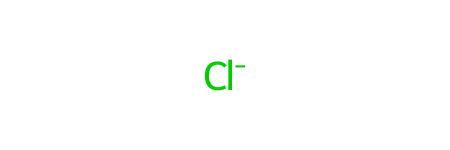

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 1 1
idx=0 Cl Number of bonds : 0
NO BONDS CREATED


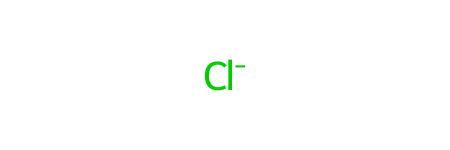

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 1 1
idx=0 Cl Number of bonds : 0
NO BONDS CREATED


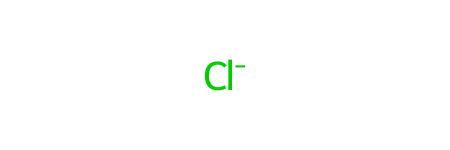

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 1 1
idx=0 Cl Number of bonds : 0
NO BONDS CREATED


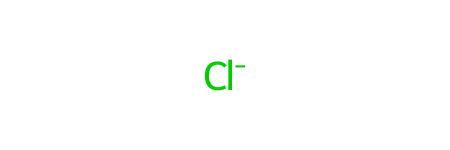

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 1 1
idx=0 Cl Number of bonds : 0
NO BONDS CREATED


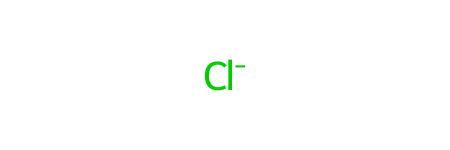

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 1 1
idx=0 Cl Number of bonds : 0
NO BONDS CREATED


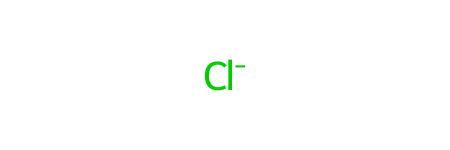

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 1 1
idx=0 Cl Number of bonds : 0
NO BONDS CREATED
CELL.CREATE_BONDS: Creating Metal-Metal Bonds for molecule Cl6-Hg2
CELL.CREATE_BONDS: Metals: [------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Hg
 Atomic Number                = 80
 Index in Molecule            = 0
 Metal Adjacency (mconnec)    = 4
 Regular Adjacencies (connec) = 4
 Atom Charge                  = 2.0
 Coordination Sphere Formula  = Cl4
 Possible Charges             = [2]
----------------------------------------------------
, ------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Hg
 Atomic Number                = 80
 Index in Molecule            = 4
 Metal Adjacency (mc

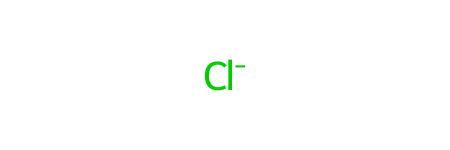

0 Cl
Cl Hg 0.5


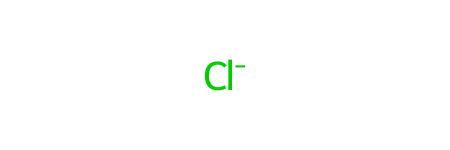

0 Cl
Cl Hg 0.5
Cl Hg 0.5


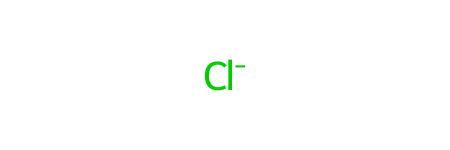

0 Cl
Cl Hg 0.5


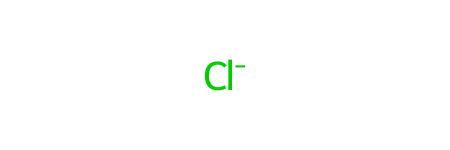

0 Cl
Cl Hg 0.5


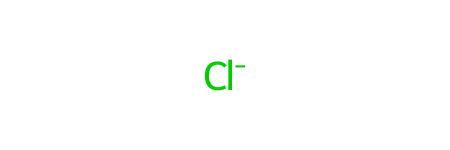

0 Cl
Cl Hg 0.5
Cl Hg 0.5


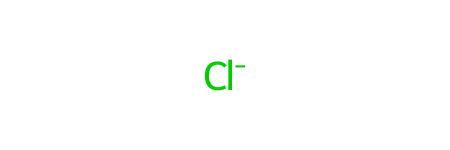

CELL.CREATE_BONDS: Creating Bonds for molecule H9-C10-Cl-Fe-Hg


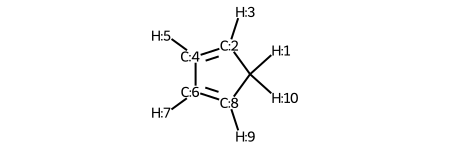

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are different: 10 11
[(0, 'C'), (1, 'H'), (2, 'C'), (3, 'H'), (4, 'C'), (5, 'H'), (6, 'C'), (7, 'H'), (8, 'C'), (9, 'H')]
[(0, 'C'), (1, 'H'), (2, 'C'), (3, 'H'), (4, 'C'), (5, 'H'), (6, 'C'), (7, 'H'), (8, 'C'), (9, 'H'), (10, 'H')]
NON_BONDED_ATOMS [10]
idx=0 C Number of bonds : 4
C : 0 , H : 1 , 1.0
BOND CREATED 0 0 1 1.0 C H
C : 0 , C : 2 , 1.0
BOND CREATED 0 0 2 1.0 C C
C : 0 , C : 8 , 1.0
BOND CREATED 0 0 8 1.0 C C
C : 0 , H : 10 , 1.0
NO BOND CREATED bond_startatom=0 or bond_endatom=10 is not in the specie.atoms. It belongs to non_bonded_atoms=[10].
BONDS [('C', 'H', 1.0, 0.931), ('C', 'C', 1.0, 1.379), ('C', 'C', 1.0, 1.382)]
idx=1 H Number of bonds : 1
C : 0 , H : 1 , 1.0
BOND CREATED 1 1 0 1.0 H C
BONDS [('H', 'C', 1.0, 0.931)]
idx=2 C Number of bonds : 3
C : 0 , C : 2 , 1.0
BOND CREATED 2 2 0 1.0 C C
C : 2 , H : 3 , 1.0
BOND CREATED 2 2 3 1.0 C H
C : 2 , C : 4 , 2.0
BOND CREATED 2 2 4 2.0 C C
BONDS [('C', 'C', 1.0,

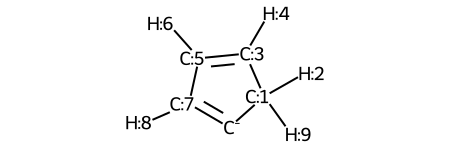

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are different: 9 10
[(0, 'C'), (1, 'C'), (2, 'H'), (3, 'C'), (4, 'H'), (5, 'C'), (6, 'H'), (7, 'C'), (8, 'H')]
[(0, 'C'), (1, 'C'), (2, 'H'), (3, 'C'), (4, 'H'), (5, 'C'), (6, 'H'), (7, 'C'), (8, 'H'), (9, 'H')]
NON_BONDED_ATOMS [9]
idx=0 C Number of bonds : 2
C : 0 , C : 1 , 1.0
BOND CREATED 0 0 1 1.0 C C
C : 0 , C : 7 , 2.0
BOND CREATED 0 0 7 2.0 C C
BONDS [('C', 'C', 1.0, 1.386), ('C', 'C', 2.0, 1.421)]
idx=1 C Number of bonds : 4
C : 0 , C : 1 , 1.0
BOND CREATED 1 1 0 1.0 C C
C : 1 , H : 2 , 1.0
BOND CREATED 1 1 2 1.0 C H
C : 1 , C : 3 , 1.0
BOND CREATED 1 1 3 1.0 C C
C : 1 , H : 9 , 1.0
NO BOND CREATED bond_startatom=1 or bond_endatom=9 is not in the specie.atoms. It belongs to non_bonded_atoms=[9].
BONDS [('C', 'C', 1.0, 1.386), ('C', 'H', 1.0, 0.93), ('C', 'C', 1.0, 1.438)]
idx=2 H Number of bonds : 1
C : 1 , H : 2 , 1.0
BOND CREATED 2 2 1 1.0 H C
BONDS [('H', 'C', 1.0, 0.93)]
idx=3 C Number of bonds : 3
C : 1 , C : 3 

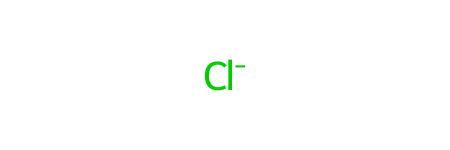

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 1 1
idx=0 Cl Number of bonds : 0
NO BONDS CREATED
CELL.CREATE_BONDS: Creating Metal-Metal Bonds for molecule H9-C10-Cl-Fe-Hg
CELL.CREATE_BONDS: Metals: [------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Hg
 Atomic Number                = 80
 Index in Molecule            = 0
 Metal Adjacency (mconnec)    = 2
 Regular Adjacencies (connec) = 2
 Atom Charge                  = 2.0
 Coordination Sphere Formula  = C-Cl
 Possible Charges             = [2]
----------------------------------------------------
, ------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Number                = 26
 Index in Molecule            = 1
 Metal Adja

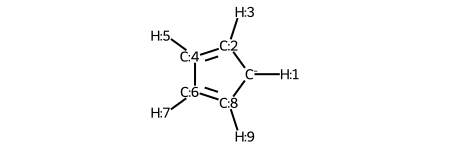

0 C
C C 1.0
0 1
C C 2.0
0 7
C Hg 0.5
C Fe 0.5
1 C
C C 1.0
1 0
C H 1.0
1 2
C C 1.0
1 3
C Fe 0.5
2 H
H C 1.0
2 1
3 C
C C 1.0
3 1
C H 1.0
3 4
C C 2.0
3 5
C Fe 0.5
4 H
H C 1.0
4 3
5 C
C C 2.0
5 3
C H 1.0
5 6
C C 1.0
5 7
C Fe 0.5
6 H
H C 1.0
6 5
7 C
C C 2.0
7 0
C C 1.0
7 5
C H 1.0
7 8
C Fe 0.5
8 H
H C 1.0
8 7


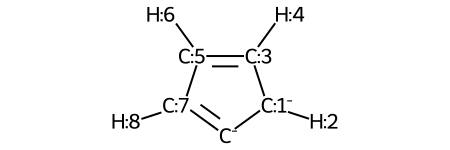

0 Cl
Cl Hg 0.5


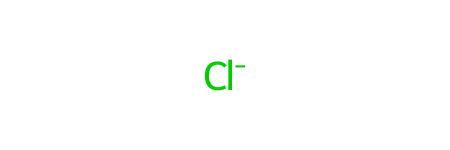

CELL.CREATE_BONDS: Creating Bonds for molecule H9-C10-Cl-Fe-Hg


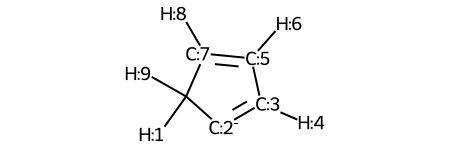

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are different: 9 10
[(0, 'C'), (1, 'H'), (2, 'C'), (3, 'C'), (4, 'H'), (5, 'C'), (6, 'H'), (7, 'C'), (8, 'H')]
[(0, 'C'), (1, 'H'), (2, 'C'), (3, 'C'), (4, 'H'), (5, 'C'), (6, 'H'), (7, 'C'), (8, 'H'), (9, 'H')]
NON_BONDED_ATOMS [9]
idx=0 C Number of bonds : 4
C : 0 , H : 1 , 1.0
BOND CREATED 0 0 1 1.0 C H
C : 0 , C : 2 , 1.0
BOND CREATED 0 0 2 1.0 C C
C : 0 , C : 7 , 1.0
BOND CREATED 0 0 7 1.0 C C
C : 0 , H : 9 , 1.0
NO BOND CREATED bond_startatom=0 or bond_endatom=9 is not in the specie.atoms. It belongs to non_bonded_atoms=[9].
BONDS [('C', 'H', 1.0, 0.93), ('C', 'C', 1.0, 1.421), ('C', 'C', 1.0, 1.426)]
idx=1 H Number of bonds : 1
C : 0 , H : 1 , 1.0
BOND CREATED 1 1 0 1.0 H C
BONDS [('H', 'C', 1.0, 0.93)]
idx=2 C Number of bonds : 2
C : 0 , C : 2 , 1.0
BOND CREATED 2 2 0 1.0 C C
C : 2 , C : 3 , 2.0
BOND CREATED 2 2 3 2.0 C C
BONDS [('C', 'C', 1.0, 1.421), ('C', 'C', 2.0, 1.386)]
idx=3 C Number of bonds : 3
C : 2 , C : 3 

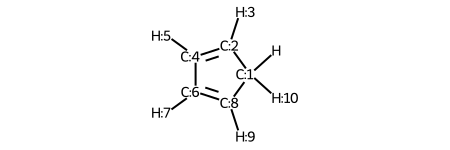

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are different: 10 11
[(0, 'H'), (1, 'C'), (2, 'C'), (3, 'H'), (4, 'C'), (5, 'H'), (6, 'C'), (7, 'H'), (8, 'C'), (9, 'H')]
[(0, 'H'), (1, 'C'), (2, 'C'), (3, 'H'), (4, 'C'), (5, 'H'), (6, 'C'), (7, 'H'), (8, 'C'), (9, 'H'), (10, 'H')]
NON_BONDED_ATOMS [10]
idx=0 H Number of bonds : 1
H : 0 , C : 1 , 1.0
BOND CREATED 0 0 1 1.0 H C
BONDS [('H', 'C', 1.0, 0.929)]
idx=1 C Number of bonds : 4
H : 0 , C : 1 , 1.0
BOND CREATED 1 1 0 1.0 C H
C : 1 , C : 2 , 1.0
BOND CREATED 1 1 2 1.0 C C
C : 1 , C : 8 , 1.0
BOND CREATED 1 1 8 1.0 C C
C : 1 , H : 10 , 1.0
NO BOND CREATED bond_startatom=1 or bond_endatom=10 is not in the specie.atoms. It belongs to non_bonded_atoms=[10].
BONDS [('C', 'H', 1.0, 0.929), ('C', 'C', 1.0, 1.373), ('C', 'C', 1.0, 1.379)]
idx=2 C Number of bonds : 3
C : 1 , C : 2 , 1.0
BOND CREATED 2 2 1 1.0 C C
C : 2 , H : 3 , 1.0
BOND CREATED 2 2 3 1.0 C H
C : 2 , C : 4 , 2.0
BOND CREATED 2 2 4 2.0 C C
BONDS [('C', 'C', 1.0,

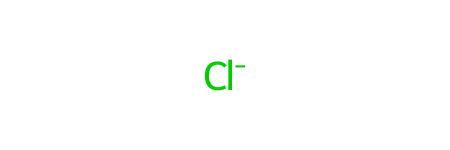

CREATE BONDS: Number of atoms in ligand object and RDKit MOL are equal: 1 1
idx=0 Cl Number of bonds : 0
NO BONDS CREATED
CELL.CREATE_BONDS: Creating Metal-Metal Bonds for molecule H9-C10-Cl-Fe-Hg
CELL.CREATE_BONDS: Metals: [------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Hg
 Atomic Number                = 80
 Index in Molecule            = 0
 Metal Adjacency (mconnec)    = 2
 Regular Adjacencies (connec) = 2
 Atom Charge                  = 2.0
 Coordination Sphere Formula  = C-Cl
 Possible Charges             = [2]
----------------------------------------------------
, ------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Number                = 26
 Index in Molecule            = 1
 Metal Adja

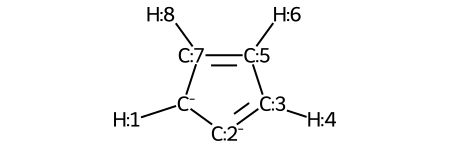

0 H
H C 1.0
0 1
1 C
C H 1.0
1 0
C C 1.0
1 2
C C 1.0
1 8
C Fe 0.5
2 C
C C 1.0
2 1
C H 1.0
2 3
C C 2.0
2 4
C Fe 0.5
3 H
H C 1.0
3 2
4 C
C C 2.0
4 2
C H 1.0
4 5
C C 1.0
4 6
C Fe 0.5
5 H
H C 1.0
5 4
6 C
C C 1.0
6 4
C H 1.0
6 7
C C 2.0
6 8
C Fe 0.5
7 H
H C 1.0
7 6
8 C
C C 1.0
8 1
C C 2.0
8 6
C H 1.0
8 9
C Fe 0.5
9 H
H C 1.0
9 8


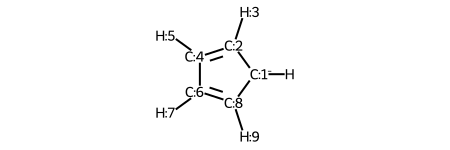

0 Cl
Cl Hg 0.5


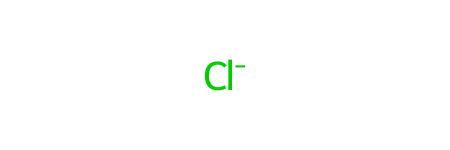

In [25]:
newcell.create_bonds(debug=debug)

In [ ]:
for mol in newcell.moleclist:
    if mol.iscomplex:
        print(mol.formula)
        print(f"{mol.smiles=}")
        print(f"{mol.smiles_with_H=}")
        for lig in mol.ligands:
            print(lig.smiles)
            display(mol_with_atom_index(lig.rdkit_obj))

In [26]:
newcell.moleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Hg2
  Has Adjacency Matrix         = YES
  Total Charge                 = -2
  Smiles                       = ['[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]']
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 22
  Formula                      = H9-C10-Cl-Fe-Hg
  Has Adjacency Matrix         = YES
  Total Charge                 = 1
  Smiles                       = ['[H]C1=C([H])[C-]([H])C([H])=C1[H]', '[H]C1=[C-][C

In [27]:
newcell.assign_spin(debug=2)

coord_group=[------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Origin                       = split_ligand
 Number of Metals             = 2
---------------------------------------------------
, ------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Origin                       = split_ligand
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms   

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Hg2
  Has Adjacency Matrix         = YES
  Total Charge                 = -2
  Spin                         = 1
  Smiles                       = ['[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]']
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 22
  Formula                      = H9-C10-Cl-Fe-Hg
  Has Adjacency Matrix         = YES
  Total Charge                 = 1
  Spin                         = 2
  Smiles      

In [28]:
for mol in newcell.moleclist:
    if mol.iscomplex:
        print(mol.formula, mol.totcharge, mol.spin)
        for met in mol.metals:
            print(met.label, met.charge, met.spin)
            print(met.coord_nr, met.coord_geometry, met.geom_deviation, met.rel_metal_radius)

Cl6-Hg2 -2 1
Hg 2.0 1
4 Tetrahedral 1.839 1.14
Hg 2.0 1
4 Tetrahedral 1.839 1.14
H9-C10-Cl-Fe-Hg 1 2
Hg 2.0 1
2 Linear 0.12 0.981
Fe 3.0 2
2 Linear 0.007 0.729
H9-C10-Cl-Fe-Hg 1 2
Hg 2.0 1
2 Linear 0.12 0.981
Fe 3.0 2
2 Linear 0.007 0.729


In [29]:
newcell.moleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Hg2
  Has Adjacency Matrix         = YES
  Total Charge                 = -2
  Spin                         = 1
  Smiles                       = ['[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]']
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 22
  Formula                      = H9-C10-Cl-Fe-Hg
  Has Adjacency Matrix         = YES
  Total Charge                 = 1
  Spin                         = 2
  Smiles      

In [ ]:
newcell.save(f"{name}/{name}.cell")